# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [ ]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score #matriz de confusión

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from scipy import stats

In [ ]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:

#cargamos los datos como arreglos numpy
#features= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_features_small.txt", delimiter=',')
#targets= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_labels_small.txt", delimiter=',')
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')


In [ ]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
De classification
2. ¿Es un problema binario o multiclase?
Es binario.
3. ¿Qué representa la variable objetivo?
La variable objetivo representa si una estrella pertenece a la categoría de estrellas variables RR Lyrae (1) o no (0).
4. ¿Las clases están balanceadas o desbalanceadas?
Las clases están fuertemente desbalanceadas, ya que las estrellas RR Lyrae son objetos muy raros en comparación con la inmensa mayoría de las demás estrellas del catálogo.
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?
Es importante porque el desbalance hace que el accuracy sea una métrica engañosa, obligando a usar precision, recall o F1-score para evaluar adecuadamente la detección de la clase rara.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

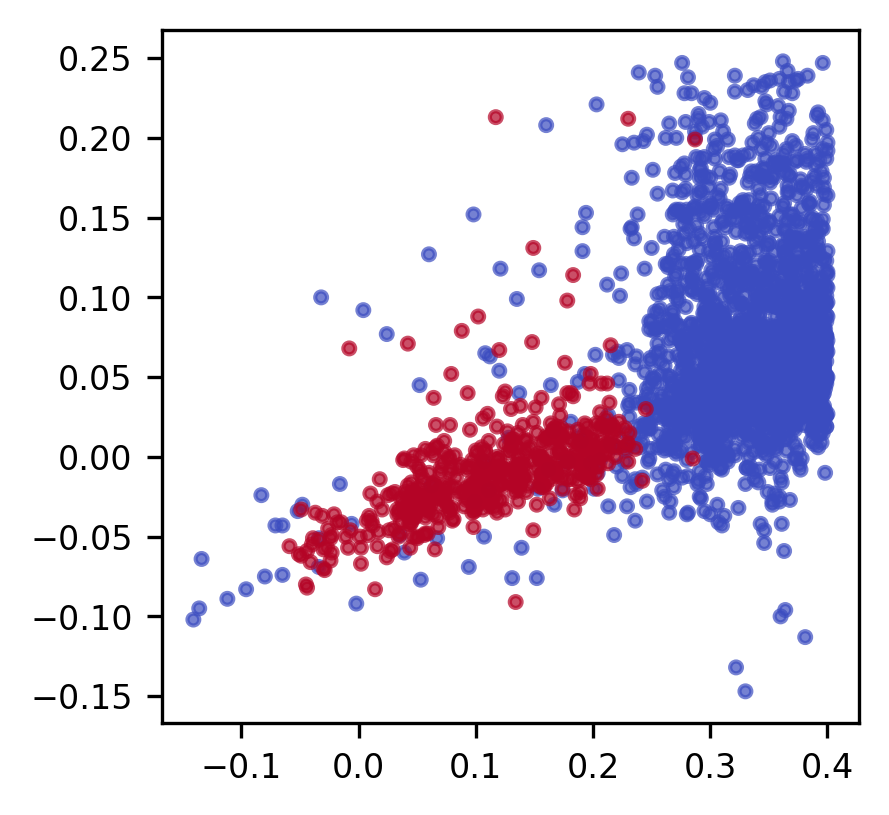

In [ ]:
#complete la celda
plt.figure(figsize=(3,3))

sc=plt.scatter(df['u-g'], df['i-z'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
No
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?
Probablemente no, porque no observo region donde las clases se separan realmente.

#### Separe los datos en entrenamiento y prueba

In [ ]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [ ]:

X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?

El conjunto de prueba podría quedarse sin suficientes estrellas RR Lyrae, alterando la proporción original de las clases.

2. ¿Por qué eso podría afectar la evaluación del modelo?

Esto afectaría la evaluación porque las métricas calculadas no serían confiables ni representativas del comportamiento real del modelo.

3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

Lo razonable es realizar una separqcion estratificada para mantener exactamente el mismo porcentaje de cada clase en ambos conjuntos.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [ ]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

In [ ]:
df.RR_Lyrae.value_counts()

,count
RR_Lyrae,
0,2000
1,483


#### Visualicemos el árbol

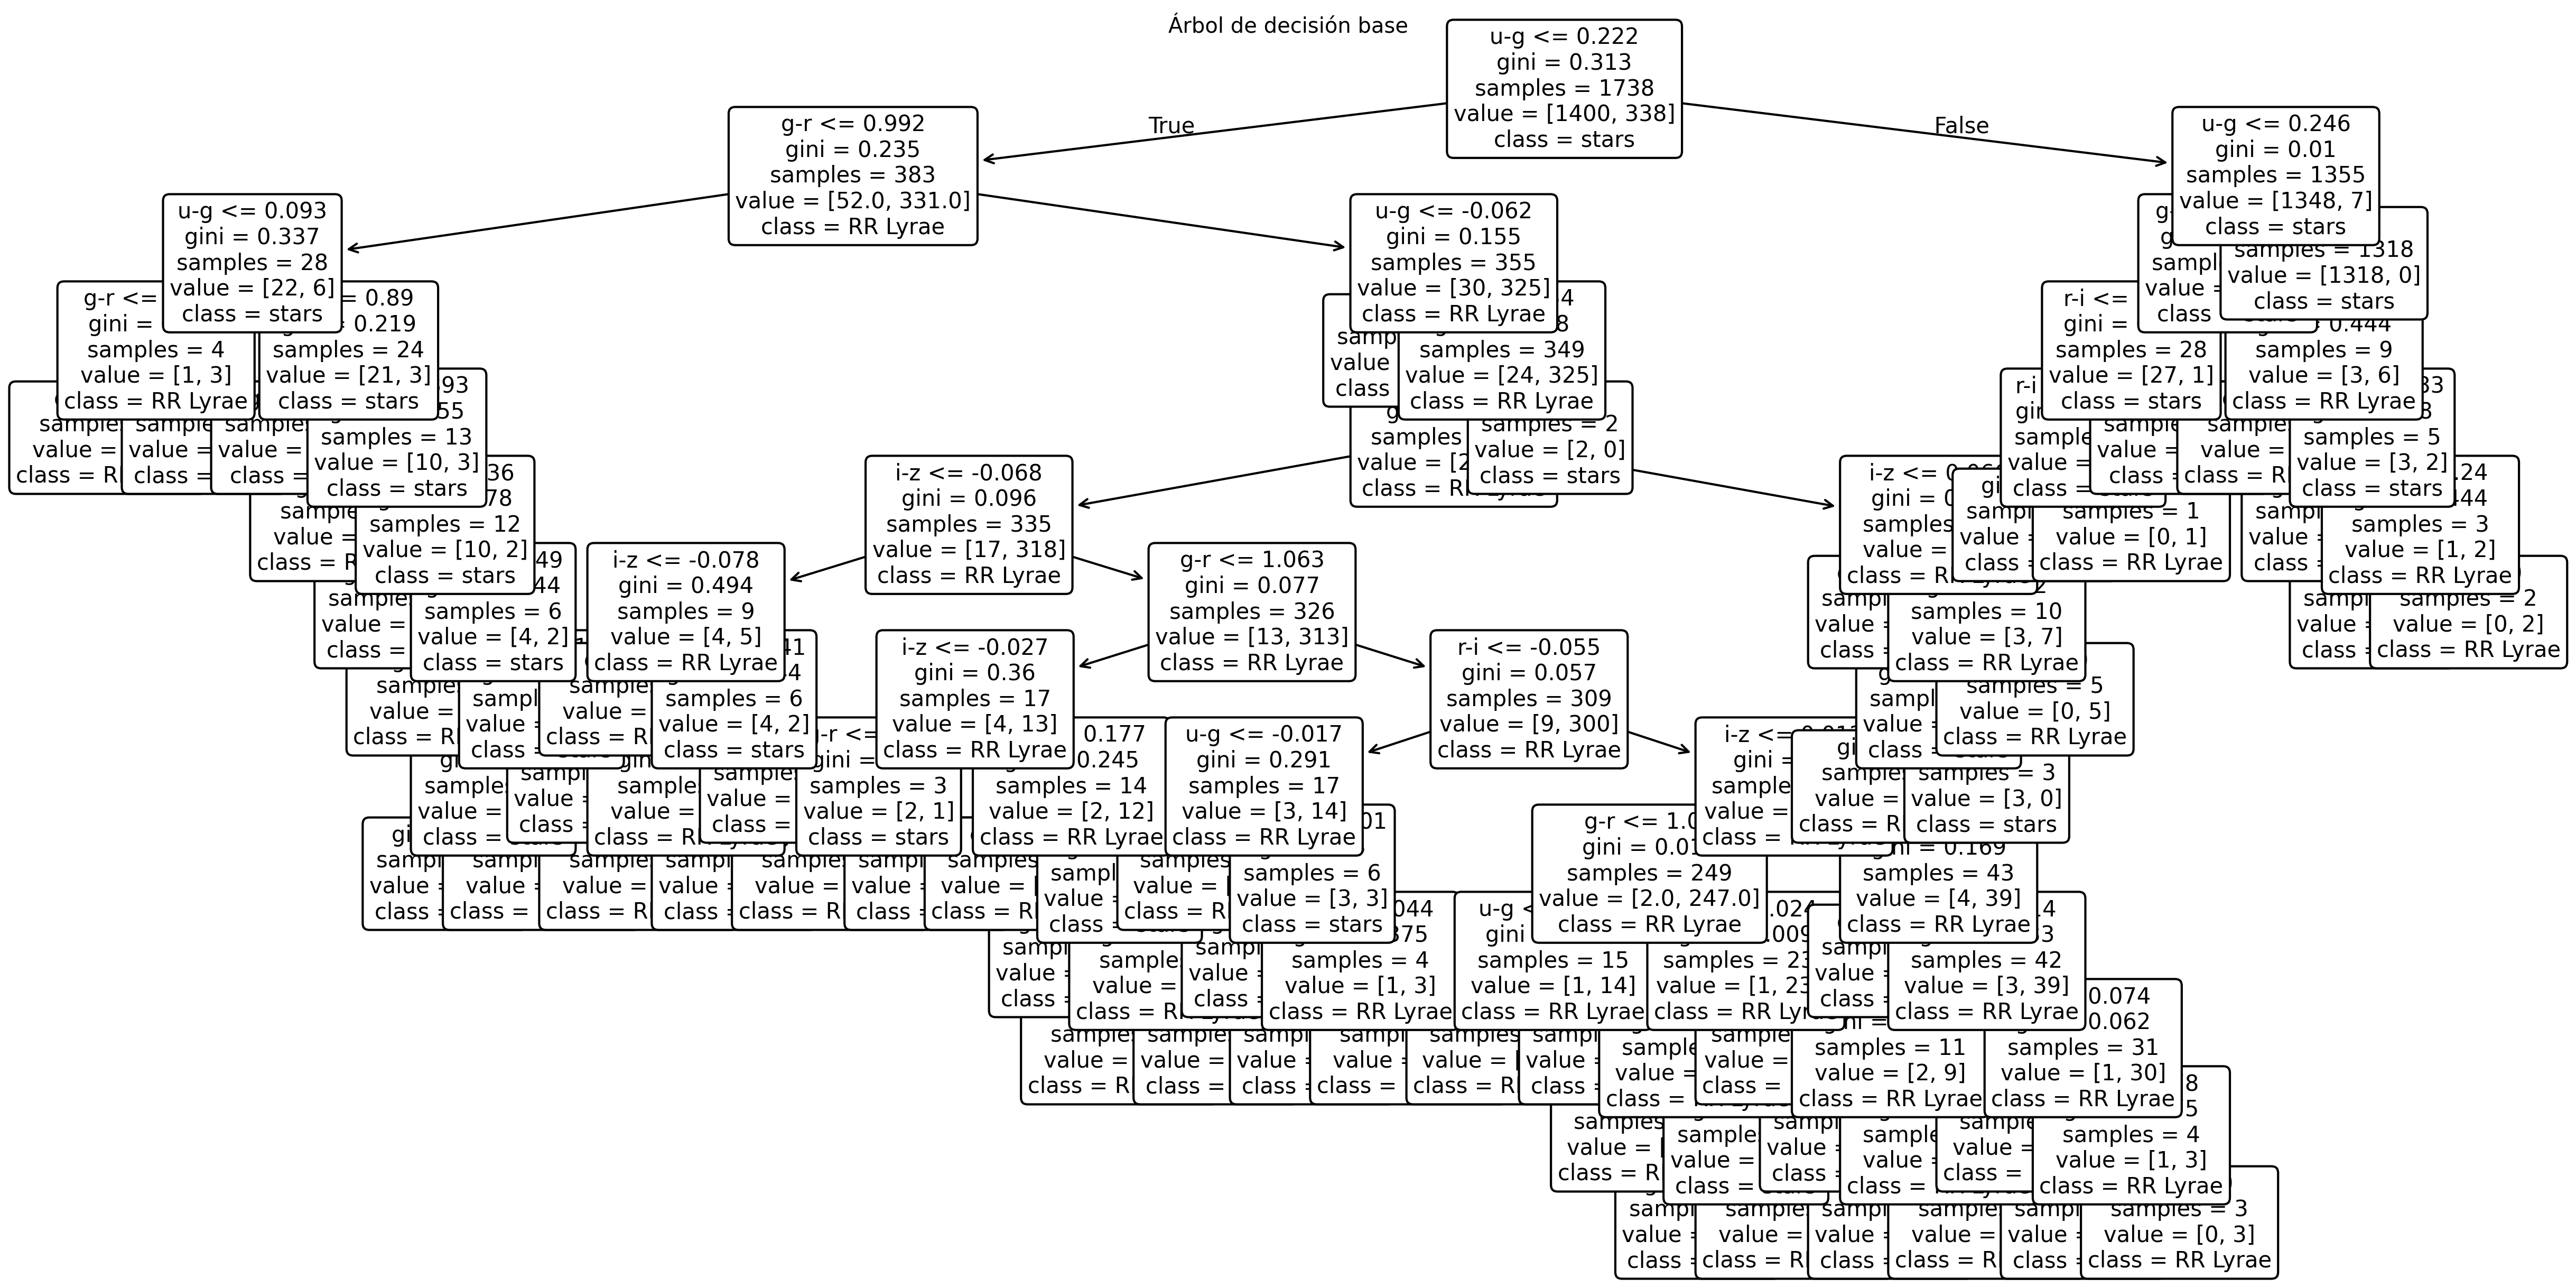

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

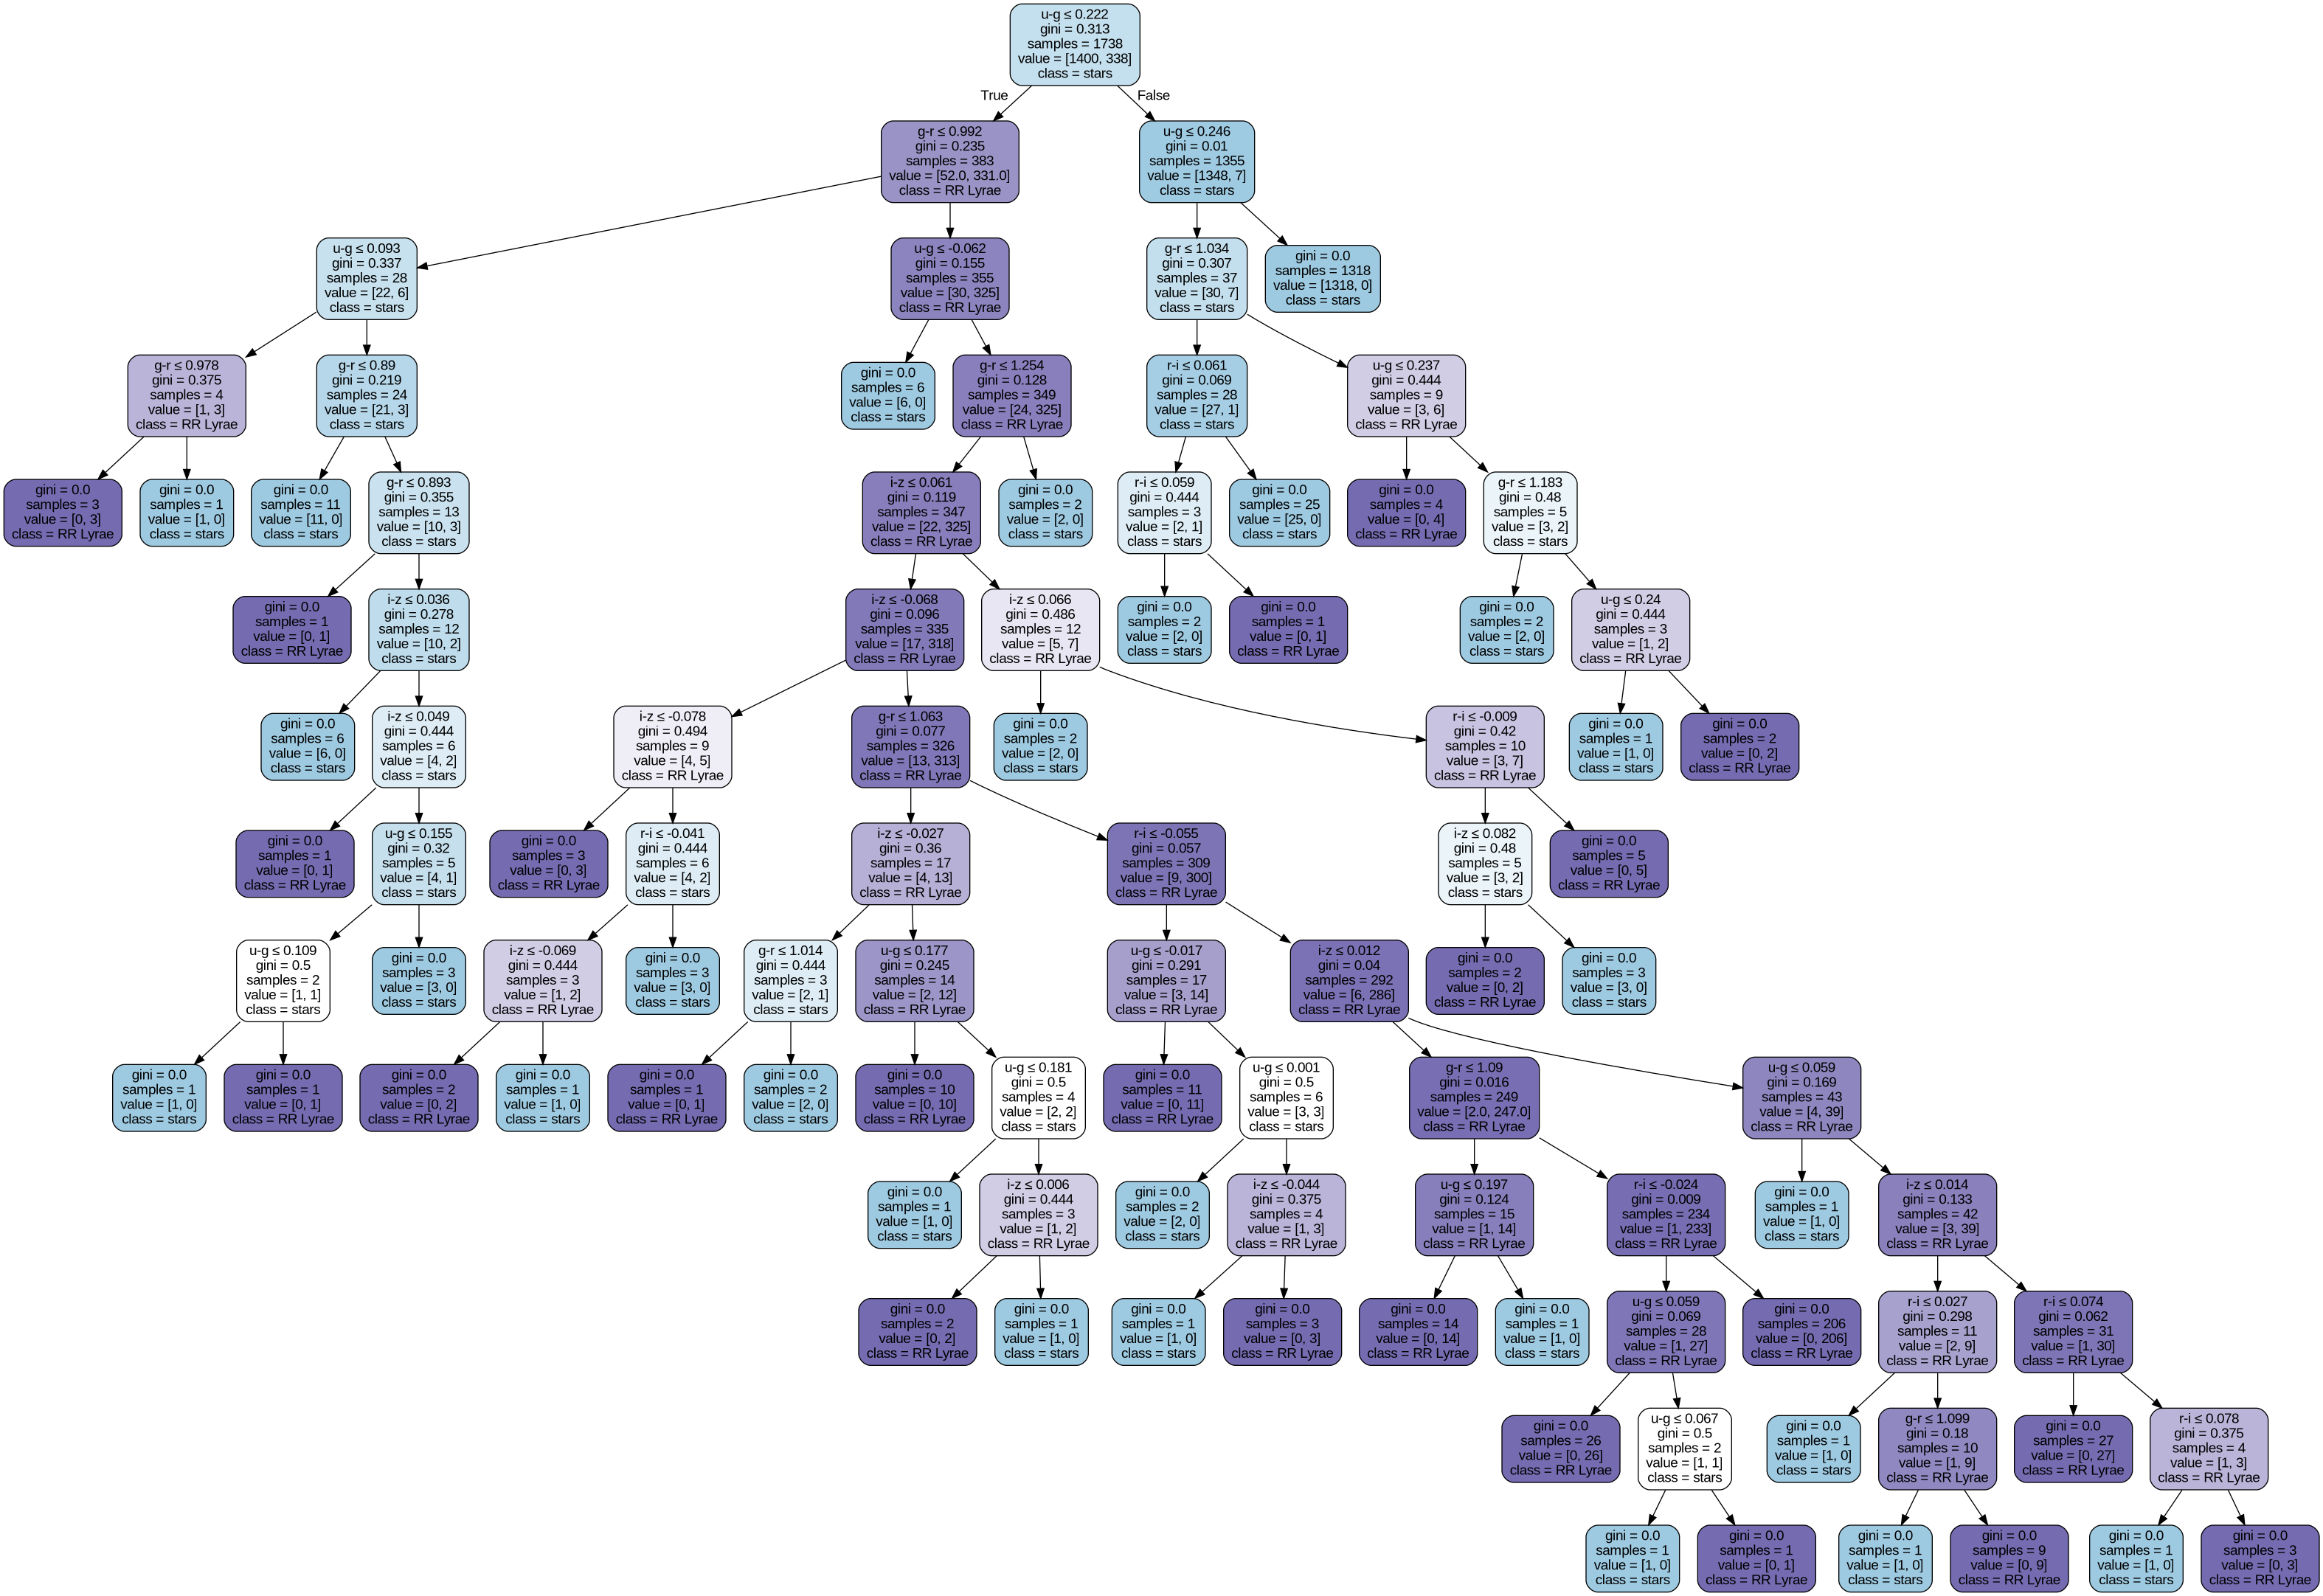

In [ ]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.

Es bastante complejo con 15 nivel, es muy profundo.

2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

Hay un riesgo de sobreajuste con este arbol.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [ ]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.978523489932886


#### Otras métricas

In [ ]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.951048951048951
Recall   : 0.9379310344827586
F1-score : 0.9444444444444444


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[593,   7],
       [  9, 136]])

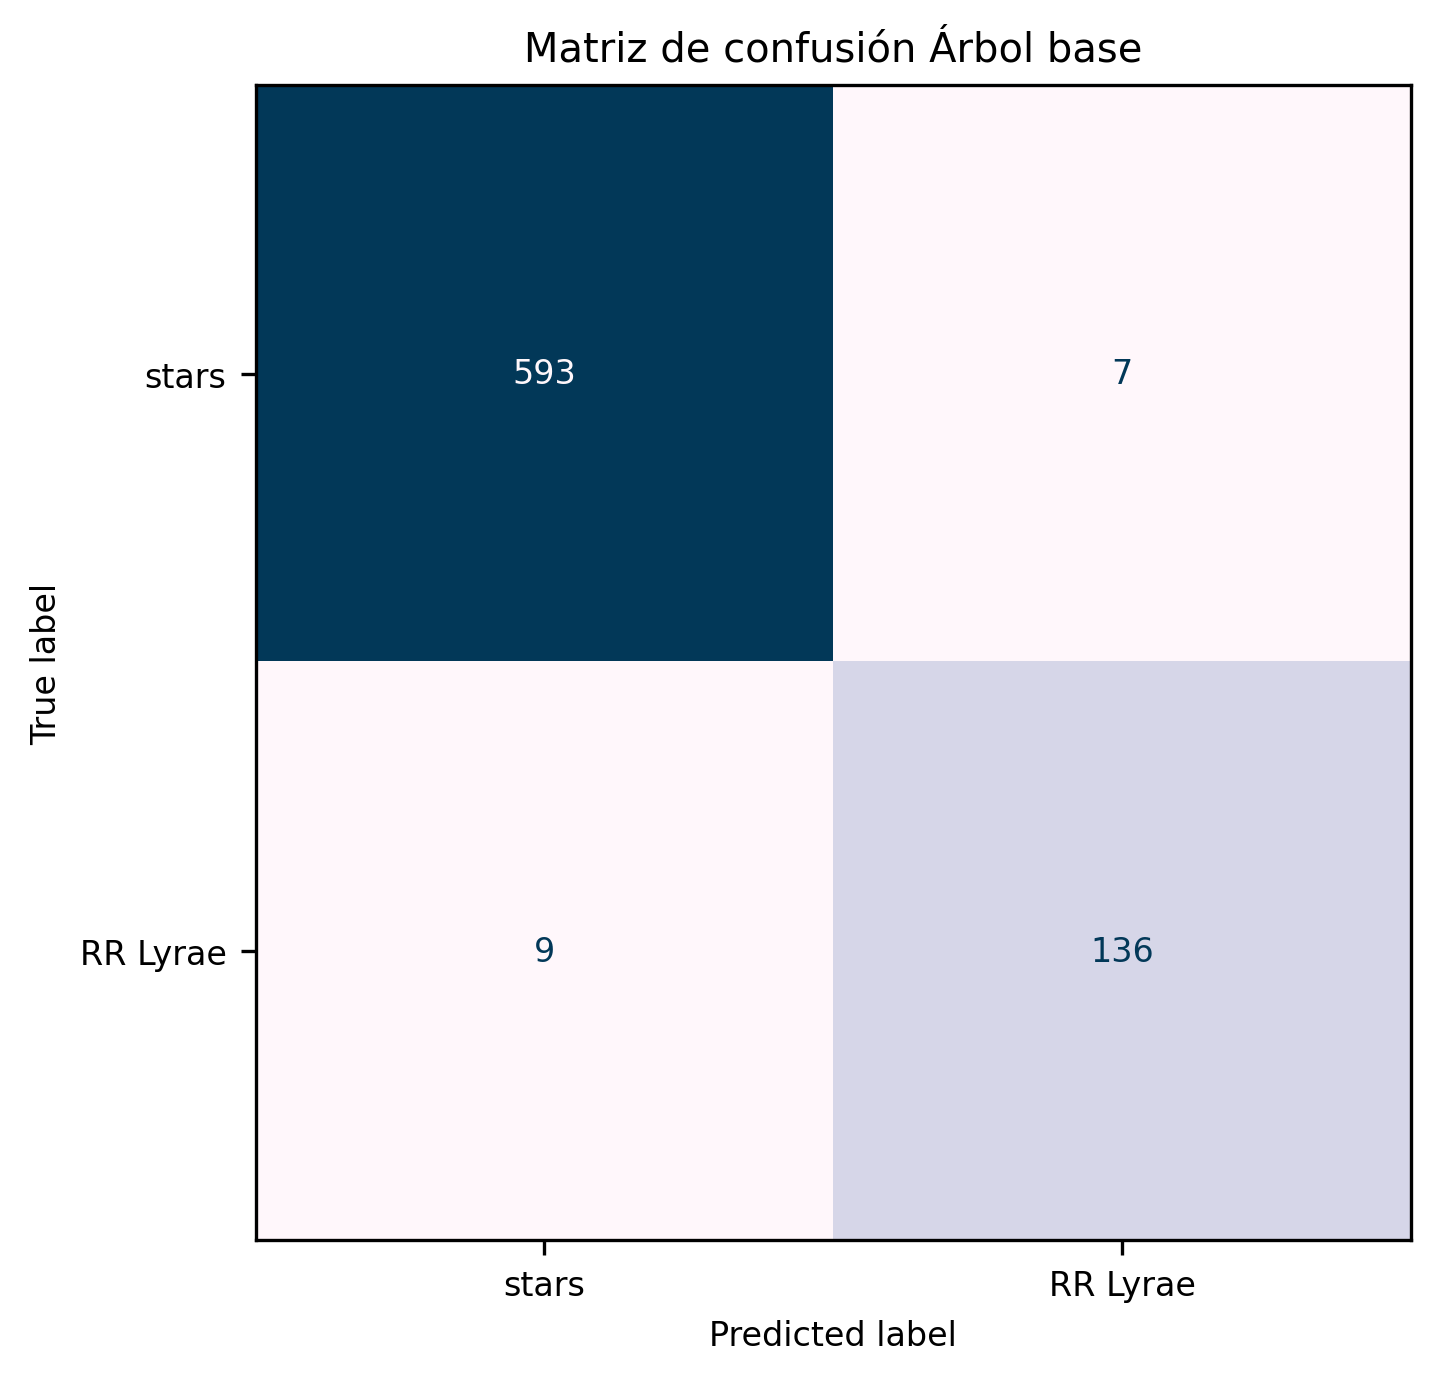

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   120
   - verdaderos negativos (TN)
   599
   - falsos positivos (FP)
   17
   - falsos negativos (FN)
   9

2. Calcule las métricas "a mano"




In [ ]:
TN,FP = cm[0,0],cm[0,1]
FN,TP = cm[1,0],cm[1,1]

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Precision : {precision}")
print(f"Recall    : {recall}")
print(f"F1-score  : {f1}")

Precision : 0.951048951048951
Recall    : 0.9379310344827586
F1-score  : 0.9444444444444445


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo

El modelo dice que una estrella es una RR Lyrae, pero en realidad es una estrella normal.

   - un falso negativo

   El modelo dice que una estrella es normal, pero en realidad sí era una RR Lyrae

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

Preocupan más los falsos negativos, porque cada uno representa una estrella RR Lyrae real que estamos perdiendo.

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

Preocupan más los falsos positivos, porque no queremos "contaminar" nuestra lista con estrellas normales equivocadas.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [ ]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [ ]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7bde7d197bc0>

In [ ]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [ ]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [ ]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [ ]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [ ]:
scores3

{'fit_time': array([0.00603819, 0.00521994, 0.00593209, 0.00610662, 0.00584841]),
 'score_time': array([0.00170374, 0.00171924, 0.00171518, 0.00170851, 0.00173068]),
 'test_score': array([0.97987928, 0.96780684, 0.96579477, 0.98185484, 0.95766129])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [ ]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.783 0.379


In [ ]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.011


In [ ]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.009


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [ ]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [ ]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [ ]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [ ]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.914 1.000
0.930 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [ ]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [ ]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [ ]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [ ]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [ ]:
np.sum(y_cv2)

np.int64(485)

In [ ]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [ ]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [ ]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [ ]:
model = DecisionTreeClassifier(random_state = 5)

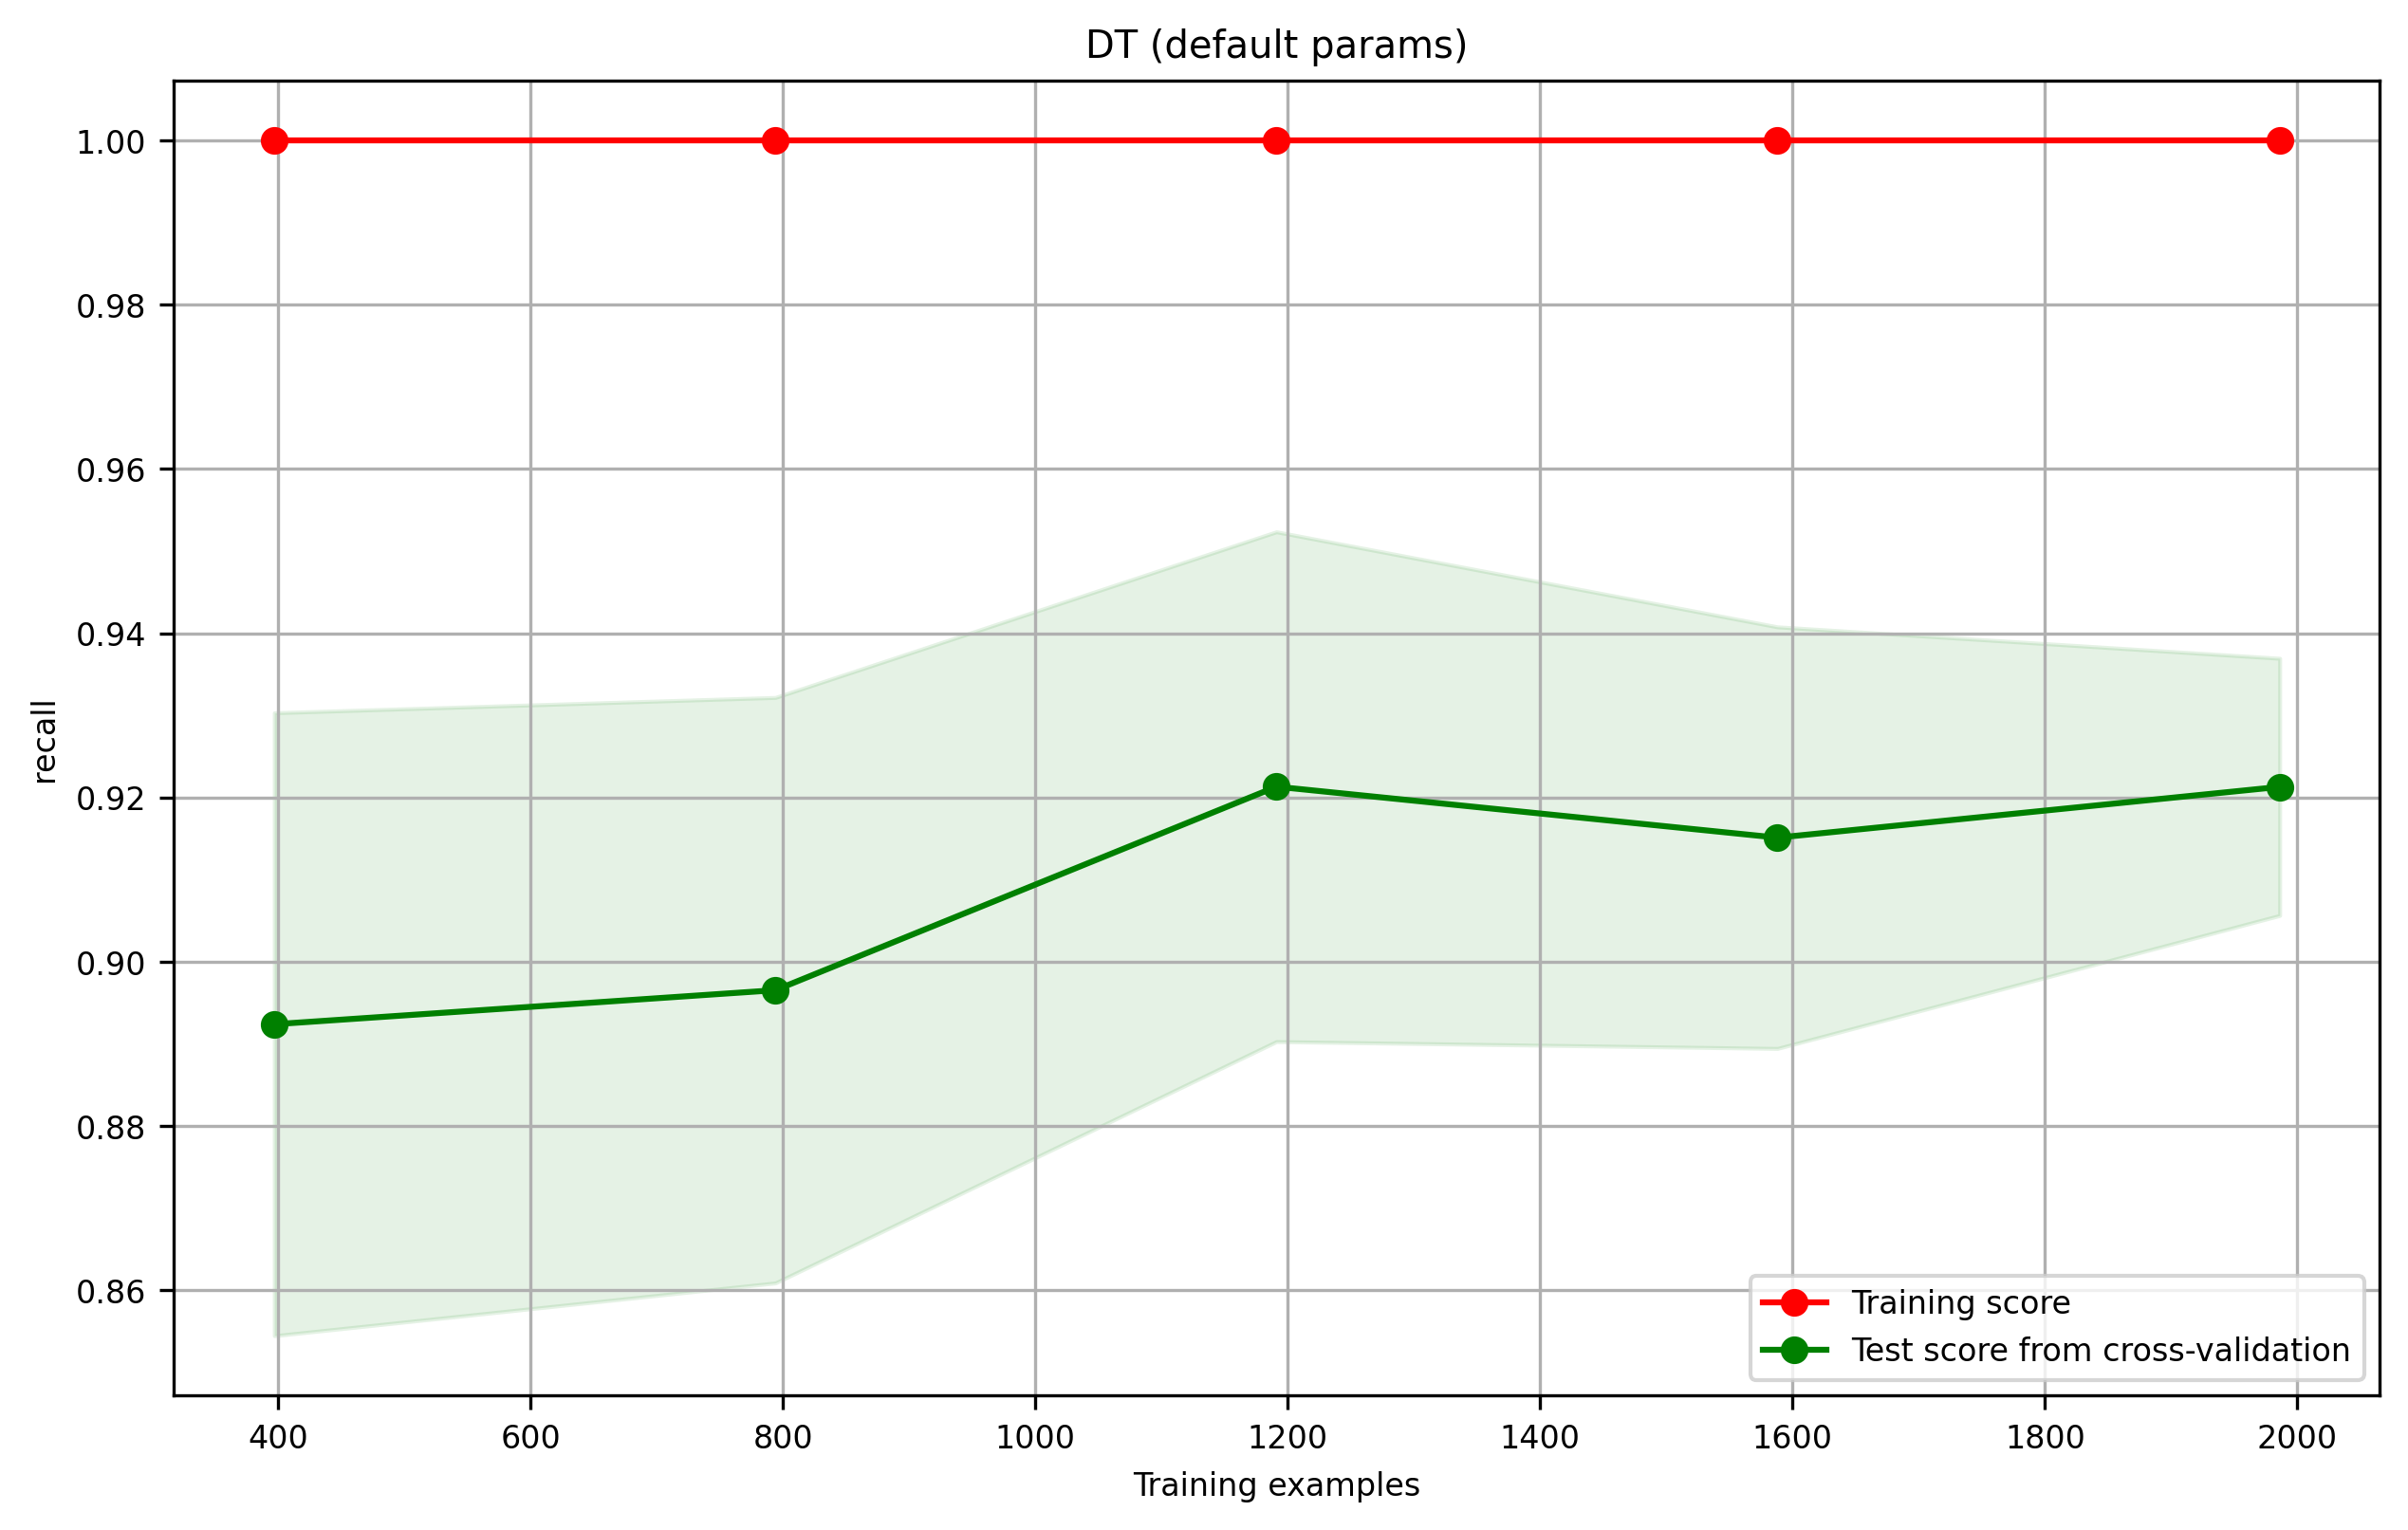

In [ ]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

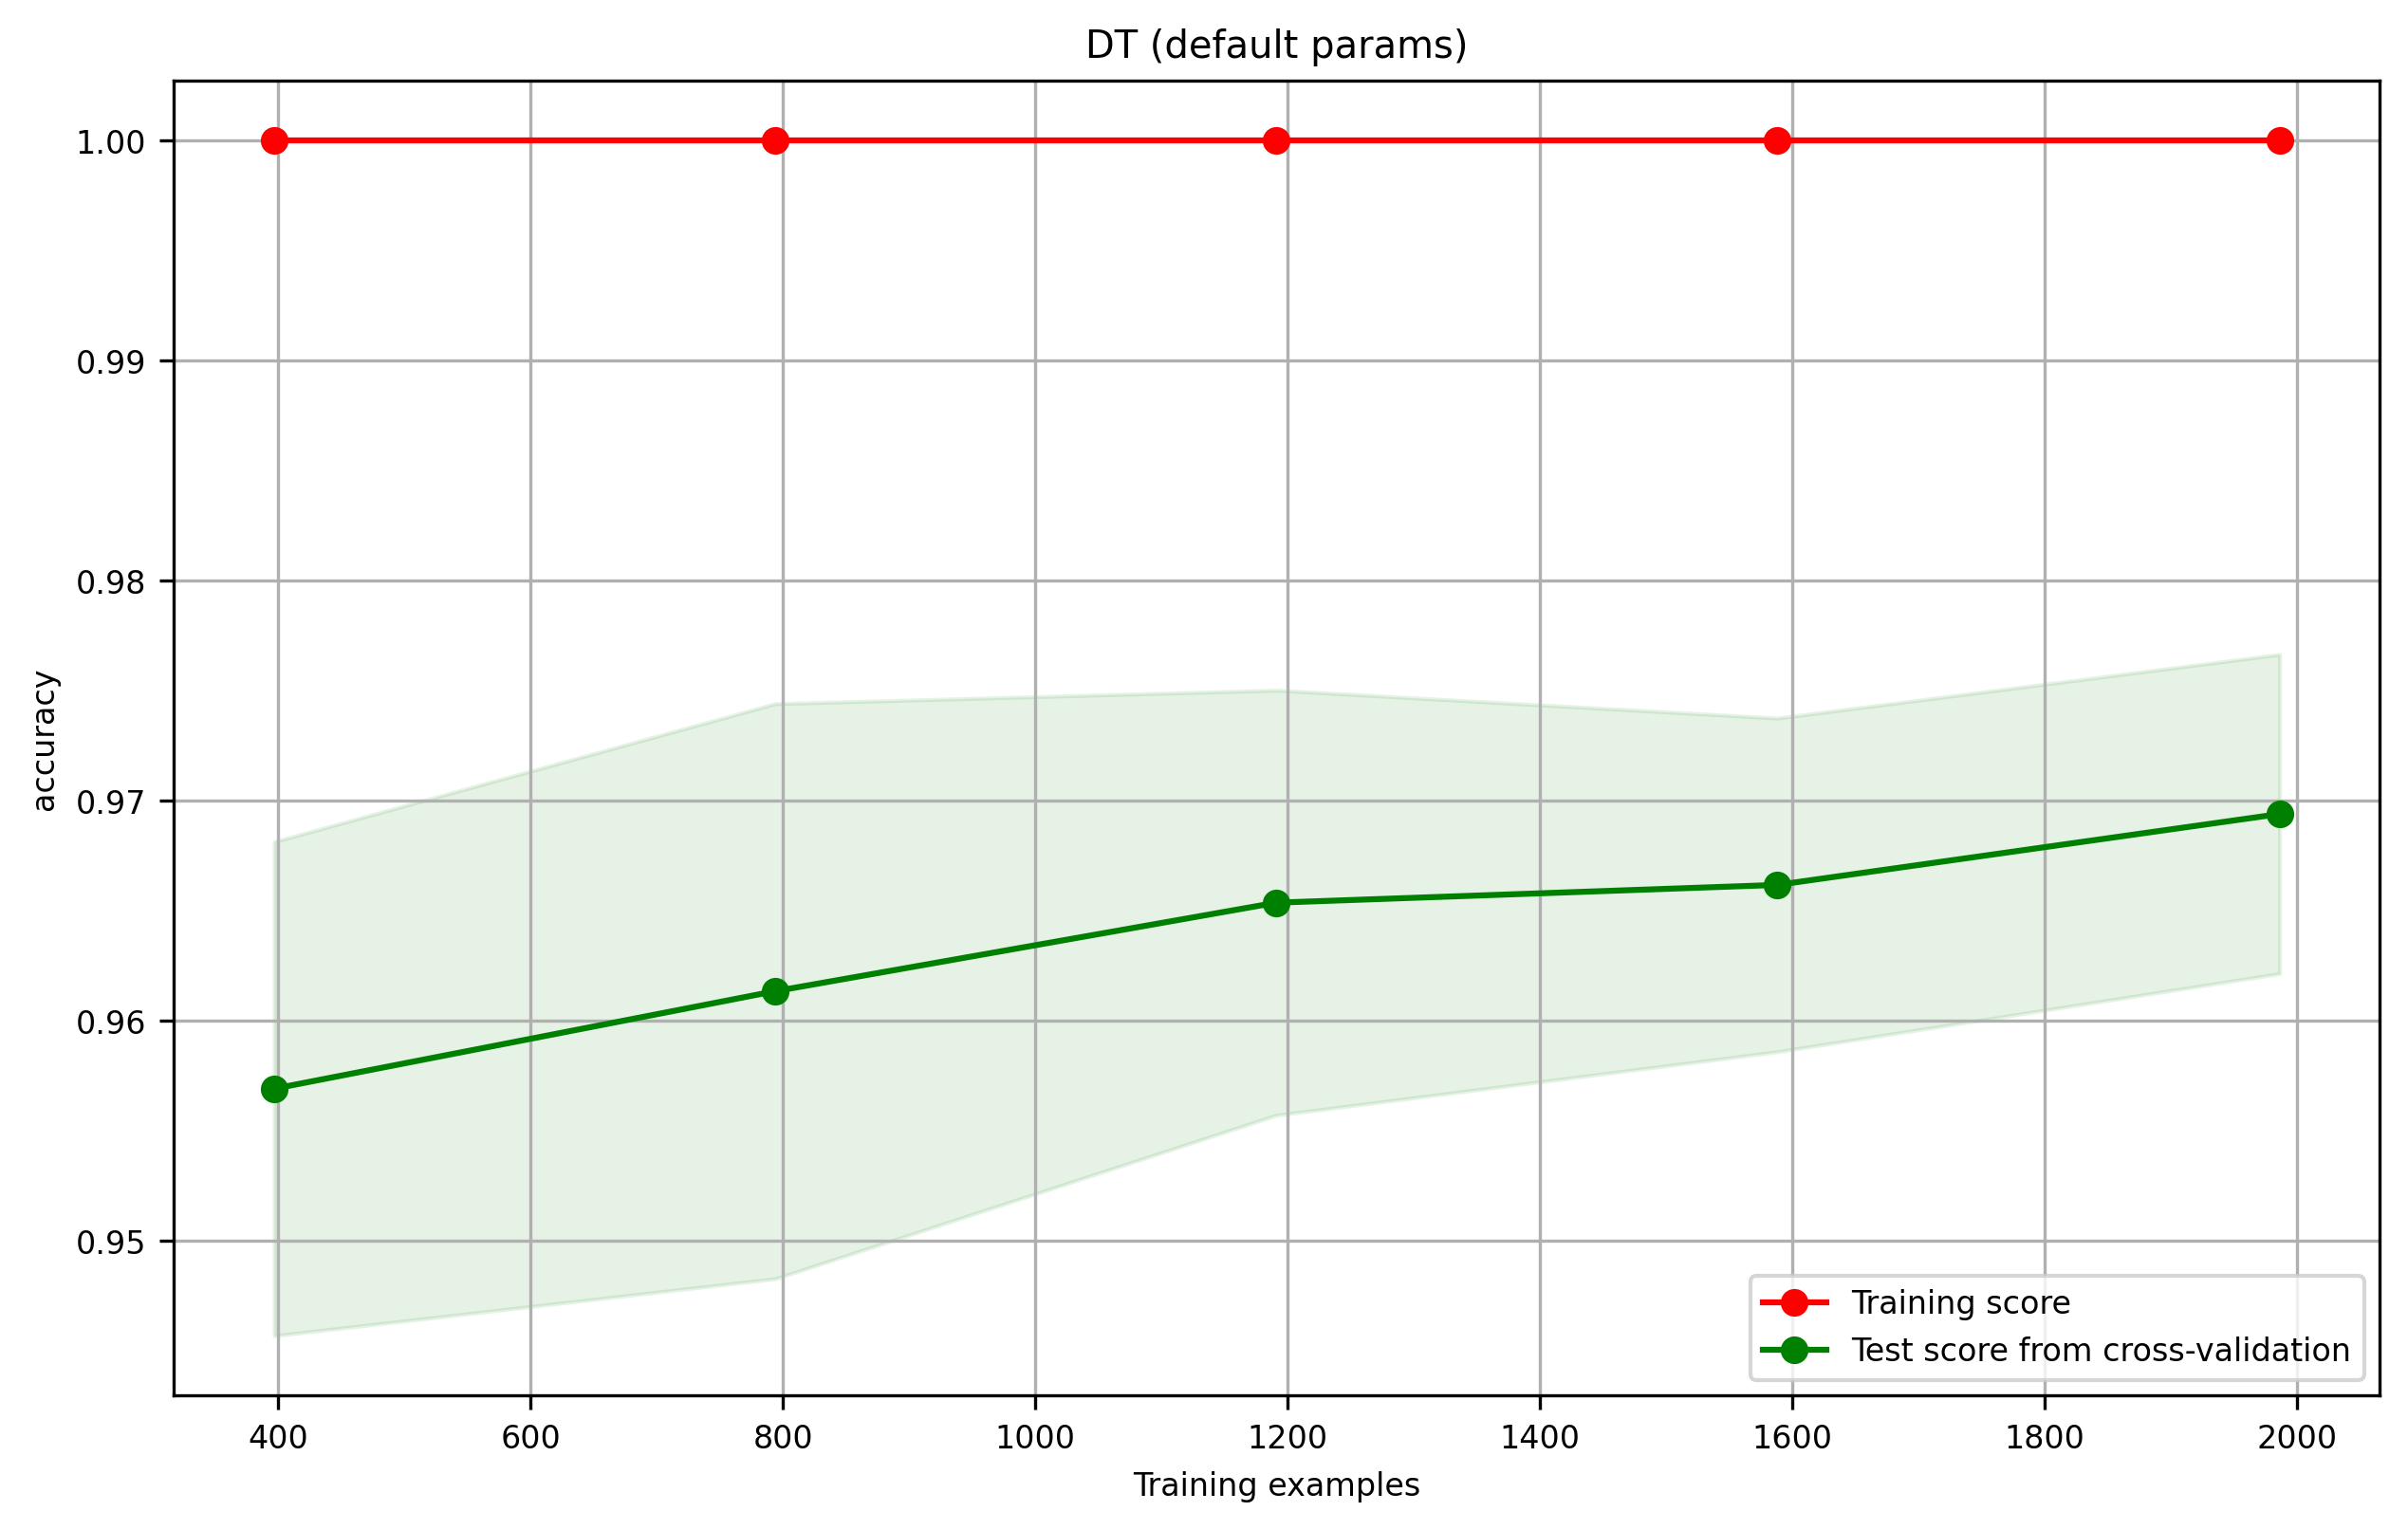

In [ ]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?

Si, existe una brecha significativa entre ambas curvas, lo que sugiere que el modelo sufre de sobreajuste al memorizar los datos de entrenamiento.

2. ¿El rendimiento de validación mejora al agregar más ejemplos?

El rendimiento de validacion mejora ligeramente al inicio con mas ejemplos, pero se estabiliza rapidamente y alcanza un limite.

3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.

Se trata de alta varianza, ya que el modelo obtiene un resultado casi perfecto en entrenamiento pero muestra una clara brecha con la validacion.

4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

En conclusion, el arbol base tiende a sobreajustar debido a su falta de restriccion, por lo que se requiere regularizar sus parametros para mejorar su generalizacion.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [ ]:
model_simple = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=10, random_state=42
)
model_simple.fit(X_train, y_train)

y_pred_base = model_tree.predict(X_test)
y_pred_simple = model_simple.predict(X_test)


results = {
    "Árbol Base": [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
    ],
    "Árbol Restringido": [
        accuracy_score(y_test, y_pred_simple),
        precision_score(y_test, y_pred_simple),
        recall_score(y_test, y_pred_simple),
        f1_score(y_test, y_pred_simple),
    ],
}


df_compare = pd.DataFrame(
    results, index=["Accuracy", "Precision", "Recall", "F1-score"]
)
df_compare

,Árbol Base,Árbol Restringido
Accuracy,0.978523,0.974497
Precision,0.951049,0.903846
Recall,0.937931,0.972414
F1-score,0.944444,0.936877


### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?

Al restringir la complejidad del arbol, la precision y el F1-score bajaron un poco, pero el recall subio bastante.

2. ¿El árbol más simple empeoró o mejoró la generalización?

El arbol mas simple empeoro ligeramente la generalizacion general, aunque mejoro la capacidad de detectar los casos positivos.

3. ¿Qué sugieren estos resultados sobre el árbol base?

Estos resultados sugieren que el arbol base no estaba tan sobreajustado y lograba un comportamiento bastante equilibrado.

4. En este problema, ¿parece conveniente usar el árbol sin restricciones?

Si, parece mas conveniente usar el arbol base porque mantiene un F1-score y una precision mas altas en general.

5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

La metrica mas importante es el recall si queremos evitar perder estrellas RR Lyrae, o el F1-score para evaluar el equilibrio global.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?

En general, el modelo kNN con un valor adecuado como k=5 supera al arbol simple en todas las metricas evaluadas.

2. ¿Qué ocurre cuando `k` es muy pequeño?

Cuando k es muy pequeño como k=2, el modelo se vuelve sensible al ruido, subiendo la precision pero bajando bastante el recall.

3. ¿Qué ocurre cuando `k` es muy grande?

Cuando k es muy grande como k=200, el modelo simplifica demasiado la frontera, lo que aumenta el recall pero reduce la precision.

4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?

El valor de k=5 parece dar el mejor equilibrio entre precision y recall, logrando el F1-score mas alto de todas las pruebas.

5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

La ventaja de kNN es que puede adaptarse a fronteras de decision mas curvas y complejas, mientras que el arbol solo realiza cortes rectos paralelos a los ejes.

In [ ]:
knn_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))]
)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1"]

scores_knn = cross_validate(knn_pipeline, X, y, cv=cv, scoring=scoring)
scores_tree = cross_validate(model_simple, X, y, cv=cv, scoring=scoring)


comparison_df = pd.DataFrame(
    {
        "Árbol Simple": [
            scores_tree["test_accuracy"].mean(),
            scores_tree["test_precision"].mean(),
            scores_tree["test_recall"].mean(),
            scores_tree["test_f1"].mean(),
        ],
        "kNN (k=5)": [
            scores_knn["test_accuracy"].mean(),
            scores_knn["test_precision"].mean(),
            scores_knn["test_recall"].mean(),
            scores_knn["test_f1"].mean(),
        ],
    },
    index=["Accuracy", "Precision", "Recall", "F1-score"],
)

comparison_df

,Árbol Simple,kNN (k=5)
Accuracy,0.972207,0.970599
Precision,0.912711,0.888898
Recall,0.948239,0.971005
F1-score,0.929971,0.928036


## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.